### Week 5 - Kenya inclusive education comprehensive dataset


## WIL PROJECT
### Program Name: Artificial Intelligence & Machine Learning
### Project Code: CPL-5559-AIMT


- Aarjeyan Shrestha (C0927422)
- Karun Kumar Atreya (C0917245)
- Sudip Chaudhary (C0922310)
- Saugat Babu Bhattarai (C0916109)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

In [3]:
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("kenya_dataset.csv")

In [5]:
df.head()

,student_id,school_id,school_name,county,distance_to_major_city_km,age,gender,disability_type,intervention_type,program_start_date,...,academic_score_endline,attendance_rate_baseline,attendance_rate_endline,social_integration_baseline,social_integration_endline,self_advocacy_baseline,self_advocacy_endline,total_cost_per_student_ksh,enrollment_status,data_quality_flag
0,STU_0001,SCH_TUR01,Turkana Primary School 1,Turkana,54.9,12,Male,Learning Disability,Infrastructure Only,2023-01-18,...,68.1,75.1,84.4,2.4,3.8,1.1,3.3,3241.0,Enrolled,Clean
1,STU_0002,SCH_TUR01,Turkana Primary School 1,Turkana,54.9,14,Female,Intellectual,Infrastructure + Technology,2023-02-07,...,72.1,73.3,92.2,2.5,3.9,1.8,4.2,15243.0,Active,Clean
2,STU_0003,SCH_TUR01,Turkana Primary School 1,Turkana,54.9,8,Male,Multiple,Infrastructure + Technology,2023-02-28,...,NaN,62.4,77.5,3.9,4.9,2.0,4.1,36661.0,Enrolled,Clean
3,STU_0004,SCH_TUR01,Turkana Primary School 1,Turkana,54.9,16,Male,Learning Disability,Infrastructure + Training,2023-02-21,...,69.6,70.2,83.6,NaN,4.1,2.4,4.0,11541.0,Enrolled,Clean
4,STU_0005,SCH_TUR01,Turkana Primary School 1,Turkana,54.9,8,Female,Mobility,Infrastructure + Technology,2023-02-16,...,74.7,64.7,79.6,3.5,5.0,2.7,NaN,41901.0,Enrolled,Clean


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1011 entries, 0 to 1010
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   student_id                    1011 non-null   object 
 1   school_id                     1011 non-null   object 
 2   school_name                   1011 non-null   object 
 3   county                        1011 non-null   object 
 4   distance_to_major_city_km     1011 non-null   float64
 5   age                           1011 non-null   int64  
 6   gender                        1011 non-null   object 
 7   disability_type               1011 non-null   object 
 8   intervention_type             1011 non-null   object 
 9   program_start_date            1011 non-null   object 
 10  baseline_assessment_date      970 non-null    object 
 11  midterm_assessment_date       930 non-null    object 
 12  endline_assessment_date       970 non-null    object 
 13  inf

### Missing Value Analysis

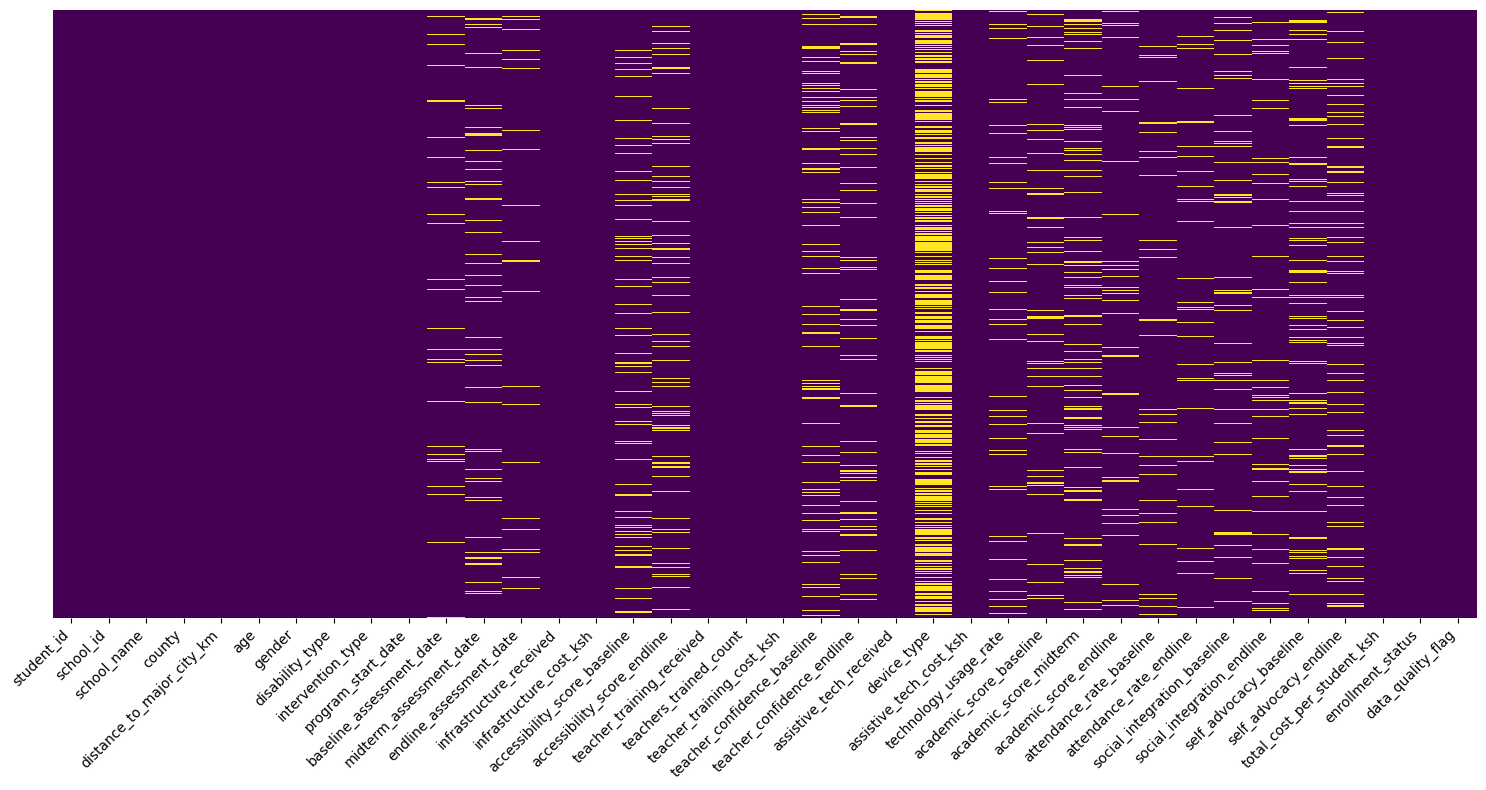

In [7]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# Check for missing values
print("Missing Values by Column:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_percent.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df)

# Check for duplicates
print(f"\nDuplicate Records: {df.duplicated().sum()}")

# Check data types
print(f"\nData Types:")
print(df.dtypes.value_counts())

Missing Values by Column:
                              Missing Count  Missing %
device_type                             540      53.41
teacher_confidence_baseline             125      12.36
academic_score_midterm                  123      12.17
self_advocacy_baseline                  120      11.87
accessibility_score_baseline            102      10.09
teacher_confidence_endline              102      10.09
self_advocacy_endline                    98       9.69
accessibility_score_endline              94       9.30
social_integration_baseline              86       8.51
midterm_assessment_date                  81       8.01
social_integration_endline               81       8.01
technology_usage_rate                    79       7.81
academic_score_baseline                  72       7.12
academic_score_endline                   68       6.73
attendance_rate_endline                  60       5.93
attendance_rate_baseline                 48       4.75
endline_assessment_date                

## Handling Missing Values - Device Type

In [9]:
df["device_type"].unique()

array([nan, 'Learning App', 'Multiple Devices', 'Walking Frame',
       'Adaptive Furniture', 'Visual Schedule', 'Talking Calculator',
       'Audio Amplifier', 'Hearing Aid', 'Braille Display',
       'Communication Tablet', 'Screen Reader', 'Wheelchair',
       'Sign Language App'], dtype=object)

In [10]:
missing_before = df['device_type'].isnull().sum()
df['device_type'] = df['device_type'].fillna('None')
missing_after = df['device_type'].isnull().sum()

print(f"Missing device_type before: {missing_before}")
print(f"Missing device_type after: {missing_after}")
print(f"Fixed: {missing_before - missing_after} missing values")

print("\nDevice type distribution:")
print(df['device_type'].value_counts())

Missing device_type before: 540
Missing device_type after: 0
Fixed: 540 missing values

Device type distribution:
device_type
None                    540
Communication Tablet     64
Walking Frame            57
Visual Schedule          54
Learning App             47
Wheelchair               43
Adaptive Furniture       42
Multiple Devices         37
Braille Display          28
Sign Language App        26
Screen Reader            25
Audio Amplifier          19
Talking Calculator       17
Hearing Aid              12
Name: count, dtype: int64


53.4% of device_type values were missing . We also have the another column called assistive_tech_received (True/False)
- If assistive_tech_received = False → Student didn't get any technology → device_type should be "None"

## Handling missing value - Teacher confident scores


In [11]:
# Check missing values in teacher confidence
print("Teacher confidence missing values:")
print(f"teacher_confidence_baseline: {df['teacher_confidence_baseline'].isnull().sum()}")
print(f"teacher_confidence_endline: {df['teacher_confidence_endline'].isnull().sum()}")

# Simple approach: Fill missing values with median
baseline_median = df['teacher_confidence_baseline'].median()
endline_median = df['teacher_confidence_endline'].median()

print(f"\nMedian values:")
print(f"Baseline median: {baseline_median}")
print(f"Endline median: {endline_median}")

# Fill missing values
df['teacher_confidence_baseline'].fillna(baseline_median, inplace=True)
df['teacher_confidence_endline'].fillna(endline_median, inplace=True)

print(f"\nAfter filling:")
print(f"teacher_confidence_baseline missing: {df['teacher_confidence_baseline'].isnull().sum()}")
print(f"teacher_confidence_endline missing: {df['teacher_confidence_endline'].isnull().sum()}")

Teacher confidence missing values:
teacher_confidence_baseline: 125
teacher_confidence_endline: 102

Median values:
Baseline median: 3.05
Endline median: 4.2

After filling:
teacher_confidence_baseline missing: 0
teacher_confidence_endline missing: 0


Using basic "MEDIAN" imputation we filled the missing values 

## Handling missing values - Academic score columns

In [12]:

# Simple median imputation for academic scores
academic_cols = ['academic_score_baseline', 'academic_score_midterm', 'academic_score_endline']

for col in academic_cols:
    missing_before = df[col].isnull().sum()
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"{col}: Filled {missing_before} missing values with median ({median_val:.1f})")



academic_score_baseline: Filled 72 missing values with median (45.5)
academic_score_midterm: Filled 123 missing values with median (58.0)
academic_score_endline: Filled 68 missing values with median (68.0)


## Handling missing values - Accessibility Scores

In [13]:

# Check missing values
print("Accessibility scores missing values:")
print(f"accessibility_score_baseline: {df['accessibility_score_baseline'].isnull().sum()}")
print(f"accessibility_score_endline: {df['accessibility_score_endline'].isnull().sum()}")

# Simple logical imputation
# Baseline: Fill with low score (schools started with poor accessibility)
baseline_missing = df['accessibility_score_baseline'].isnull().sum()
df['accessibility_score_baseline'].fillna(25, inplace=True)  # Low baseline score

# Endline: Fill with baseline + improvement for infrastructure schools, or baseline for others
endline_missing = df['accessibility_score_endline'].isnull().sum()

# For students who received infrastructure improvements
infra_mask = df['infrastructure_received'] == True
non_infra_mask = df['infrastructure_received'] == False

# Infrastructure schools: baseline + 40 points improvement
mask_infra_missing = infra_mask & df['accessibility_score_endline'].isnull()
df.loc[mask_infra_missing, 'accessibility_score_endline'] = df.loc[mask_infra_missing, 'accessibility_score_baseline'] + 40

# Non-infrastructure schools: baseline + small improvement (5 points)
mask_non_infra_missing = non_infra_mask & df['accessibility_score_endline'].isnull()
df.loc[mask_non_infra_missing, 'accessibility_score_endline'] = df.loc[mask_non_infra_missing, 'accessibility_score_baseline'] + 5

print(f"\nFilled {baseline_missing} baseline scores with 25 (poor starting point)")
print(f"Filled {endline_missing} endline scores based on infrastructure received")

print(f"\nAfter filling:")
print(f"accessibility_score_baseline missing: {df['accessibility_score_baseline'].isnull().sum()}")
print(f"accessibility_score_endline missing: {df['accessibility_score_endline'].isnull().sum()}")

Accessibility scores missing values:
accessibility_score_baseline: 102
accessibility_score_endline: 94

Filled 102 baseline scores with 25 (poor starting point)
Filled 94 endline scores based on infrastructure received

After filling:
accessibility_score_baseline missing: 0
accessibility_score_endline missing: 0


**Baseline scores**: Filled missing values with 25 (representing poor starting accessibility in Kenyan schools)

**Endline scores**: Used logical imputation:

- Schools with infrastructure improvements: +40 points (big improvement)
- Schools without infrastructure: +5 points (small natural improvement)

## Handle Missing Values - (Social Integration & Self Advocacy)

In [14]:

# Check missing values for social scores
social_cols = ['social_integration_baseline', 'social_integration_endline', 
               'self_advocacy_baseline', 'self_advocacy_endline']

print("Social scores missing values:")
for col in social_cols:
    missing_count = df[col].isnull().sum()
    print(f"{col}: {missing_count}")

# Simple median imputation for all social scores
for col in social_cols:
    missing_before = df[col].isnull().sum()
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Filled {missing_before} missing {col} with median ({median_val:.1f})")

print(f"\nAfter filling:")
for col in social_cols:
    print(f"{col}: {df[col].isnull().sum()} missing")

Social scores missing values:
social_integration_baseline: 86
social_integration_endline: 81
self_advocacy_baseline: 120
self_advocacy_endline: 98
Filled 86 missing social_integration_baseline with median (3.0)
Filled 81 missing social_integration_endline with median (4.2)
Filled 120 missing self_advocacy_baseline with median (2.0)
Filled 98 missing self_advocacy_endline with median (3.7)

After filling:
social_integration_baseline: 0 missing
social_integration_endline: 0 missing
self_advocacy_baseline: 0 missing
self_advocacy_endline: 0 missing


## Handle Missing Values - (Attendance Rates)

In [15]:
# Check missing values for attendance
attendance_cols = ['attendance_rate_baseline', 'attendance_rate_endline']

print("Attendance rates missing values:")
for col in attendance_cols:
    missing_count = df[col].isnull().sum()
    print(f"{col}: {missing_count}")

# Simple median imputation for attendance rates
for col in attendance_cols:
    missing_before = df[col].isnull().sum()
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Filled {missing_before} missing {col} with median ({median_val:.1f}%)")

print(f"\nAfter filling:")
for col in attendance_cols:
    print(f"{col}: {df[col].isnull().sum()} missing")

Attendance rates missing values:
attendance_rate_baseline: 48
attendance_rate_endline: 60
Filled 48 missing attendance_rate_baseline with median (70.4%)
Filled 60 missing attendance_rate_endline with median (87.4%)

After filling:
attendance_rate_baseline: 0 missing
attendance_rate_endline: 0 missing


## Handle Missing Values - (Technology Usage Rate)

In [16]:

# Check missing values for technology usage
print(f"technology_usage_rate missing: {df['technology_usage_rate'].isnull().sum()}")

# Logical imputation based on whether student received technology
tech_received = df['assistive_tech_received'] == True
tech_not_received = df['assistive_tech_received'] == False

print(f"Students who received technology: {tech_received.sum()}")
print(f"Students who did NOT receive technology: {tech_not_received.sum()}")

# Fill missing technology usage rates
missing_before = df['technology_usage_rate'].isnull().sum()

# Students who didn't receive technology should have 0% usage
no_tech_missing = tech_not_received & df['technology_usage_rate'].isnull()
df.loc[no_tech_missing, 'technology_usage_rate'] = 0

# Students who received technology but usage is missing - fill with median of tech users
tech_users_median = df[tech_received]['technology_usage_rate'].median()
tech_missing = tech_received & df['technology_usage_rate'].isnull()
df.loc[tech_missing, 'technology_usage_rate'] = tech_users_median

print(f"\nFilled {no_tech_missing.sum()} non-tech students with 0% usage")
print(f"Filled {tech_missing.sum()} tech students with median usage ({tech_users_median:.2f})")

print(f"\nAfter filling:")
print(f"technology_usage_rate missing: {df['technology_usage_rate'].isnull().sum()}")

technology_usage_rate missing: 79
Students who received technology: 471
Students who did NOT receive technology: 540

Filled 0 non-tech students with 0% usage
Filled 79 tech students with median usage (0.74)

After filling:
technology_usage_rate missing: 0


Logic behind imputation:
- No technology = 0% usage (makes perfect sense)
- Has technology but missing usage = median of other tech users (reasonable estimate)

## Handle Missing Values - (Assessment Dates)

In [17]:

# Check missing values for assessment dates
date_cols = ['baseline_assessment_date', 'midterm_assessment_date', 'endline_assessment_date']

print("Assessment dates missing values:")
for col in date_cols:
    missing_count = df[col].isnull().sum()
    print(f"{col}: {missing_count}")

# Fill missing dates with reasonable program timeline
baseline_missing = df['baseline_assessment_date'].isnull().sum()
df['baseline_assessment_date'].fillna('2023-01-15', inplace=True)

midterm_missing = df['midterm_assessment_date'].isnull().sum()
df['midterm_assessment_date'].fillna('2023-07-15', inplace=True)

endline_missing = df['endline_assessment_date'].isnull().sum()
df['endline_assessment_date'].fillna('2024-01-15', inplace=True)

print(f"\nFilled missing dates:")
print(f"Baseline: {baseline_missing} filled with 2023-01-15")
print(f"Midterm: {midterm_missing} filled with 2023-07-15")
print(f"Endline: {endline_missing} filled with 2024-01-15")

print(f"\nAfter filling:")
for col in date_cols:
    print(f"{col}: {df[col].isnull().sum()} missing")

Assessment dates missing values:
baseline_assessment_date: 41
midterm_assessment_date: 81
endline_assessment_date: 41

Filled missing dates:
Baseline: 41 filled with 2023-01-15
Midterm: 81 filled with 2023-07-15
Endline: 41 filled with 2024-01-15

After filling:
baseline_assessment_date: 0 missing
midterm_assessment_date: 0 missing
endline_assessment_date: 0 missing


What we did and why? (for dates)
- Filled missing assessment dates with standard program timeline dates
- Used realistic 6-month intervals between assessments (Jan → Jul → Jan)
- Why fixed dates: Creates consistent timeline for PowerBI time series analysis

## After Handling missing value - Data Missingness Analysis heatmap

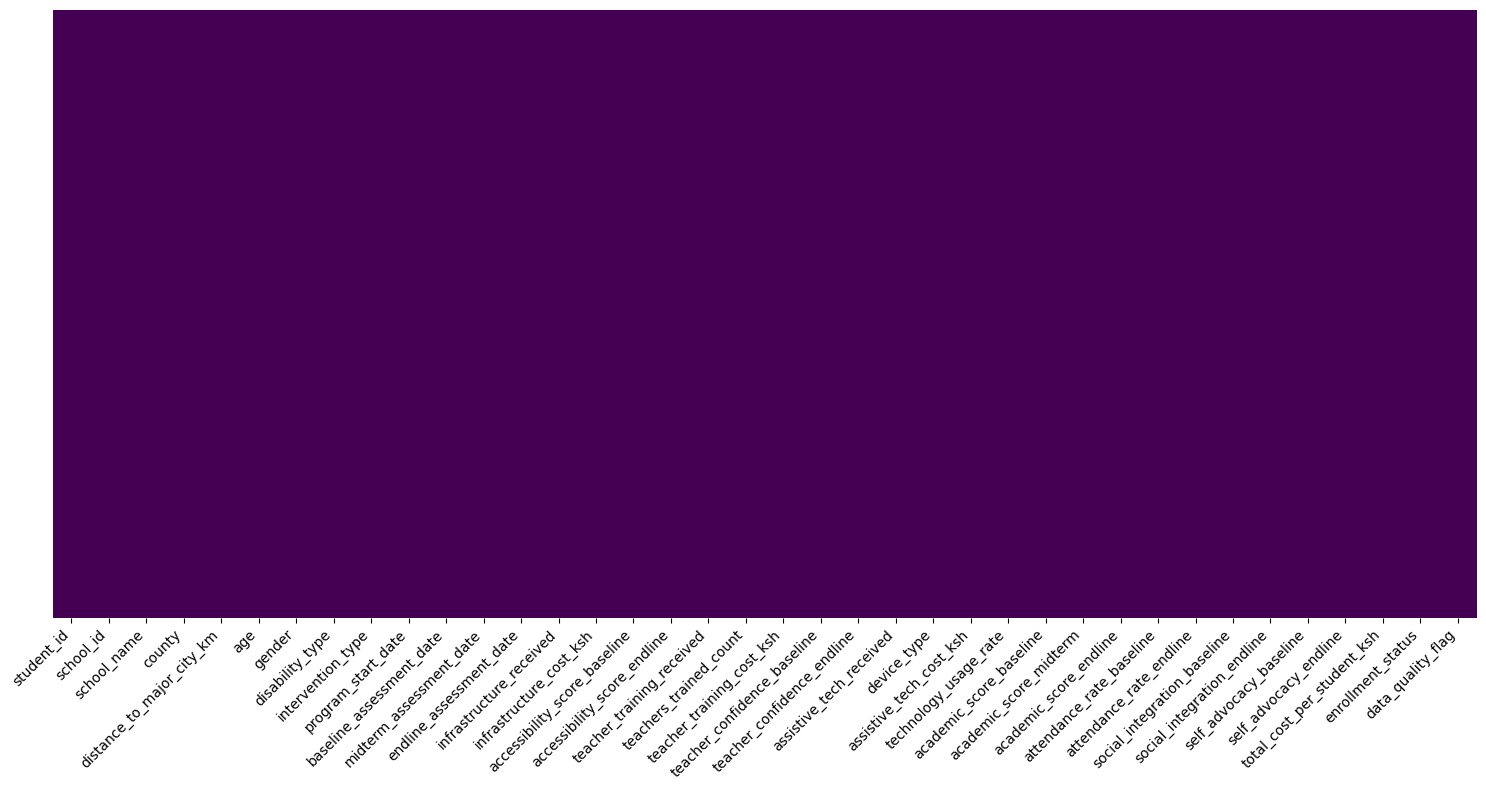

In [18]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap="viridis")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Handled all the Missing data 

## Cleaning Categorical Data - (Disability Types & Enrollment Status)

In [19]:
# Check current disability type variations
print("Current disability_type values:")
print(df['disability_type'].value_counts())
print(f"\nUnique values: {df['disability_type'].nunique()}")

# Check for inconsistencies (case sensitivity, spelling variations)
unique_disabilities = df['disability_type'].unique()
print(f"\nAll unique values: {unique_disabilities}")


Current disability_type values:
disability_type
intellectual             102
Learning Disability       94
Intellectual              90
Cognitive                 86
Mobility                  71
Physical Disability       70
Physical                  69
physical                  65
Hearing Impaired          42
visual                    33
Visual                    32
multiple                  31
Visually Impaired         28
Hard of Hearing           26
Low Vision                26
hearing                   26
Blind                     25
Deaf                      22
Hearing                   22
Multiple Disabilities     19
Complex Needs             17
Multiple                  15
Name: count, dtype: int64

Unique values: 22

All unique values: ['Learning Disability' 'Intellectual' 'Multiple' 'Mobility'
 'Physical Disability' 'Visually Impaired' 'Hard of Hearing'
 'intellectual' 'physical' 'Physical' 'Visual' 'Hearing Impaired' 'Deaf'
 'Blind' 'Low Vision' 'Cognitive' 'Multiple Disabilitie

In [20]:
# Standardize disability types
disability_mapping = {
    'visual': 'Visual',
    'Visual': 'Visual', 
    'Blind': 'Visual',
    'Low Vision': 'Visual',
    'Visually Impaired': 'Visual',
    
    'hearing': 'Hearing',
    'Hearing': 'Hearing',
    'Deaf': 'Hearing', 
    'Hard of Hearing': 'Hearing',
    'Hearing Impaired': 'Hearing',
    
    'physical': 'Physical',
    'Physical': 'Physical',
    'Mobility': 'Physical',
    'Physical Disability': 'Physical',
    
    'intellectual': 'Intellectual',
    'Intellectual': 'Intellectual',
    'Cognitive': 'Intellectual',
    'Learning Disability': 'Intellectual',
    
    'multiple': 'Multiple',
    'Multiple': 'Multiple',
    'Multiple Disabilities': 'Multiple',
    'Complex Needs': 'Multiple'
}

# Apply mapping
df['disability_type'] = df['disability_type'].map(disability_mapping).fillna(df['disability_type'])

print(f"\nAfter standardization:")
print(df['disability_type'].value_counts())
print(f"Unique values: {df['disability_type'].nunique()}")


After standardization:
disability_type
Intellectual    372
Physical        275
Visual          144
Hearing         138
Multiple         82
Name: count, dtype: int64
Unique values: 5


In [21]:
df["disability_type"].unique()

array(['Intellectual', 'Multiple', 'Physical', 'Visual', 'Hearing'],
      dtype=object)

- Identified all variations in disability_type column (case differences, synonyms)
- Created mapping dictionary to standardize similar terms
- Applied standardization to reduce from multiple variations to 5 clean categories

In [22]:
# Enrollment Status 
# Check current enrollment status variations
print("Current enrollment_status values:")
print(df['enrollment_status'].value_counts())
print(f"\nUnique values: {df['enrollment_status'].nunique()}")

# Check for case inconsistencies
unique_enrollment = df['enrollment_status'].unique()
print(f"\nAll unique values: {unique_enrollment}")

# Standardize enrollment status
enrollment_mapping = {
    'enrolled': 'Enrolled',
    'Enrolled': 'Enrolled',
    'ENROLLED': 'Enrolled',
    'Active': 'Enrolled',
    'active': 'Enrolled'
}

# Apply mapping
original_values = df['enrollment_status'].value_counts()
df['enrollment_status'] = df['enrollment_status'].map(enrollment_mapping).fillna(df['enrollment_status'])

print(f"\nAfter standardization:")
print(df['enrollment_status'].value_counts())
print(f"Unique values: {df['enrollment_status'].nunique()}")



Current enrollment_status values:
enrollment_status
Enrolled    698
Active      113
enrolled    102
ENROLLED     98
Name: count, dtype: int64

Unique values: 4

All unique values: ['Enrolled' 'Active' 'ENROLLED' 'enrolled']

After standardization:
enrollment_status
Enrolled    1011
Name: count, dtype: int64
Unique values: 1


In [23]:
df.duplicated().sum()

0

## Handling duplicates if any

In [24]:
# Check for student ID duplicates (including _DUP suffix from our original data)
duplicate_student_ids = df[df['student_id'].str.contains('_DUP', na=False)]
print(f"Student IDs with '_DUP' suffix: {len(duplicate_student_ids)}")

if len(duplicate_student_ids) > 0:
    print("\nRemoving duplicate student records...")
    print("Sample duplicate IDs:")
    print(duplicate_student_ids['student_id'].head())
    
    # Remove records with _DUP suffix
    rows_before = len(df)
    df = df[~df['student_id'].str.contains('_DUP', na=False)]
    rows_after = len(df)
    removed_count = rows_before - rows_after
    
    print(f"Removed {removed_count} duplicate records")
    print(f"Dataset shape: {rows_before} → {rows_after} rows")
else:
    print("No '_DUP' suffix duplicates found")

print(f"\nFinal dataset shape: {df.shape}")

Student IDs with '_DUP' suffix: 15

Removing duplicate student records...
Sample duplicate IDs:
996     STU_0347_DUP
997     STU_0692_DUP
998     STU_0359_DUP
999     STU_0985_DUP
1000    STU_0144_DUP
Name: student_id, dtype: object
Removed 15 duplicate records
Dataset shape: 1011 → 996 rows

Final dataset shape: (996, 38)


## Standardize Date Formats

In [25]:

# Check current date formats
date_columns = ['program_start_date', 'baseline_assessment_date', 'midterm_assessment_date', 'endline_assessment_date']

print("Current date formats:")
for col in date_columns:
    print(f"\n{col}:")
    print("Sample values:")
    sample_dates = df[col].dropna().head(5).tolist()
    for date in sample_dates:
        print(f"  {date}")
    print(f"Data type: {df[col].dtype}")

# Convert all date columns to proper datetime format
print(f"\nConverting to datetime format...")

for col in date_columns:
    print(f"Processing {col}...")
    # Convert to datetime, handling multiple formats
    df[col] = pd.to_datetime(df[col], infer_datetime_format=True, errors='coerce')
    
    # Check for any dates that couldn't be converted
    nat_count = df[col].isnull().sum()
    if nat_count > 0:
        print(f"  Warning: {nat_count} dates could not be parsed")
    else:
        print(f"  Success: All dates converted")

print(f"\nAfter conversion:")
for col in date_columns:
    print(f"{col}: {df[col].dtype}")
    print(f"  Sample: {df[col].dropna().iloc[0]}")

print(f"\nDate standardization completed!")

Current date formats:

program_start_date:
Sample values:
  2023-01-18
  2023-02-07
  2023-02-28
  2023-02-21
  2023-02-16
Data type: object

baseline_assessment_date:
Sample values:
  2022-11-25
  2022-12-29
  2022-12-04
  30/12/2022
  25/12/2022
Data type: object

midterm_assessment_date:
Sample values:
  2023-07-30
  2023-08-22
  2023-09-01
  2023-08-24
  2023-08-25
Data type: object

endline_assessment_date:
Sample values:
  2024-04-20
  2024-05-09
  2024-06-19
  2024-07-24
  2024-07-21
Data type: object

Converting to datetime format...
Processing program_start_date...
  Success: All dates converted
Processing baseline_assessment_date...
Processing midterm_assessment_date...
Processing endline_assessment_date...

After conversion:
program_start_date: datetime64[ns]
  Sample: 2023-01-18 00:00:00
baseline_assessment_date: datetime64[ns]
  Sample: 2022-11-25 00:00:00
midterm_assessment_date: datetime64[ns]
  Sample: 2023-07-30 00:00:00
endline_assessment_date: datetime64[ns]
  Sample

In [27]:
print("FIXING PROBLEMATIC DATES")

# Check which dates have issues
date_columns = ['baseline_assessment_date', 'midterm_assessment_date', 'endline_assessment_date']

for col in date_columns:
    null_count = df[col].isnull().sum()
    print(f"{col}: {null_count} null dates")

# Fill null dates with reasonable program timeline dates
print("\nFilling problematic dates with program timeline...")

# Fill missing baseline dates
baseline_nulls = df['baseline_assessment_date'].isnull().sum()
df['baseline_assessment_date'] = df['baseline_assessment_date'].fillna(pd.to_datetime('2023-01-15'))

# Fill missing midterm dates  
midterm_nulls = df['midterm_assessment_date'].isnull().sum()
df['midterm_assessment_date'] = df['midterm_assessment_date'].fillna(pd.to_datetime('2023-07-15'))

# Fill missing endline dates
endline_nulls = df['endline_assessment_date'].isnull().sum()
df['endline_assessment_date'] = df['endline_assessment_date'].fillna(pd.to_datetime('2024-01-15'))

print(f"Fixed {baseline_nulls} baseline dates")
print(f"Fixed {midterm_nulls} midterm dates") 
print(f"Fixed {endline_nulls} endline dates")

print(f"\nFinal check:")
for col in date_columns:
    print(f"{col}: {df[col].isnull().sum()} null dates remaining")
    print(f"  Data type: {df[col].dtype}")

FIXING PROBLEMATIC DATES
baseline_assessment_date: 104 null dates
midterm_assessment_date: 87 null dates
endline_assessment_date: 103 null dates

Filling problematic dates with program timeline...
Fixed 104 baseline dates
Fixed 87 midterm dates
Fixed 103 endline dates

Final check:
baseline_assessment_date: 0 null dates remaining
  Data type: datetime64[ns]
midterm_assessment_date: 0 null dates remaining
  Data type: datetime64[ns]
endline_assessment_date: 0 null dates remaining
  Data type: datetime64[ns]


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 996 entries, 0 to 995
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   student_id                    996 non-null    object        
 1   school_id                     996 non-null    object        
 2   school_name                   996 non-null    object        
 3   county                        996 non-null    object        
 4   distance_to_major_city_km     996 non-null    float64       
 5   age                           996 non-null    int64         
 6   gender                        996 non-null    object        
 7   disability_type               996 non-null    object        
 8   intervention_type             996 non-null    object        
 9   program_start_date            996 non-null    datetime64[ns]
 10  baseline_assessment_date      996 non-null    datetime64[ns]
 11  midterm_assessment_date       996 non